# TH-EVI: Thailand EV Infrastructure Demand Model
## Pilot Province: เชียงใหม่ (Chiang Mai)

**Inspired by NREL EVI-Pro methodology**, adapted for Thailand context.

### Objectives:
1. ทดสอบ EV Adoption S-curve สำหรับเชียงใหม่ → 2030-2040
2. ประมาณการ daily EV charging demand ตามจุดต่างๆ ในเชียงใหม่
3. Visualize ผลลัพธ์สำหรับ proposal/executive summary

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from th_evi.adoption import EVAdoptionModel
from th_evi.location import LocationDemandModel, LANDMARK_DB

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. EV Adoption Forecast: เชียงใหม่

In [2]:
model = EVAdoptionModel(province='เชียงใหม่')

years = list(range(2025, 2041))
shares = [model.get_ev_share(y) for y in years]
populations = [model.get_ev_population(y) for y in years]

df_adoption = pd.DataFrame({
    'year': years,
    'ev_share_pct': [round(s*100, 1) for s in shares],
    'ev_population': populations
})
df_adoption.head(10)

,year,ev_share_pct,ev_population
0,2025,6.6,121463
1,2026,8.5,160177
2,2027,11.0,209194
3,2028,13.9,269342
4,2029,17.3,341285
5,2030,21.3,424715
6,2031,25.5,517668
7,2032,30.0,617430
8,2033,34.5,720068
9,2034,38.7,821407


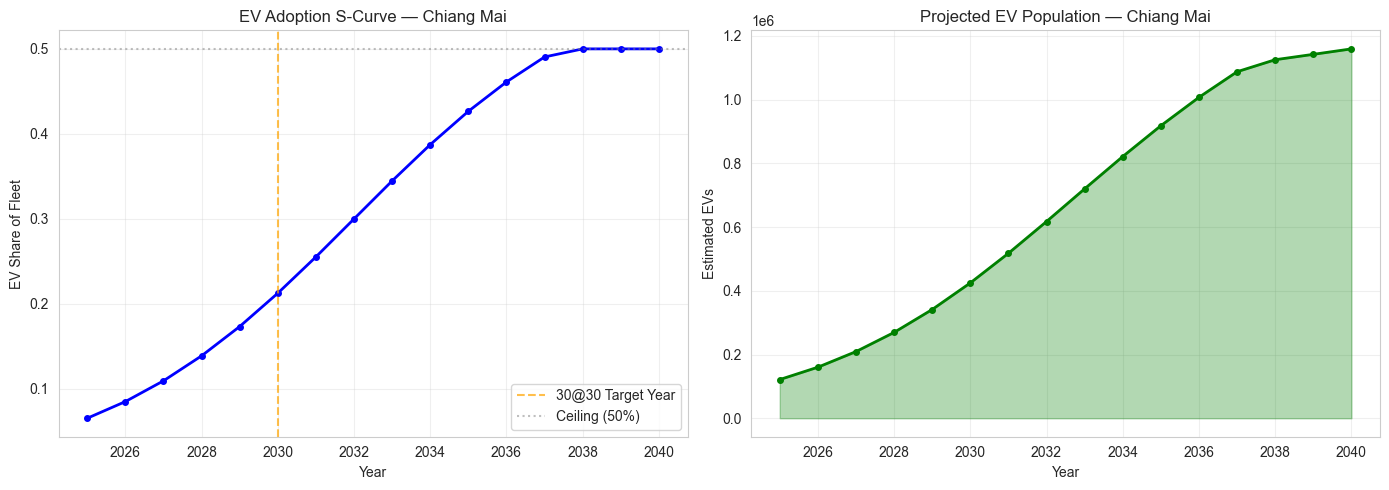

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: EV Share S-Curve
ax1.plot(years, shares, 'b-o', linewidth=2, markersize=4)
ax1.axvline(2030, color='orange', linestyle='--', alpha=0.7, label='30@30 Target Year')
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Ceiling (50%)')
ax1.set_xlabel('Year'); ax1.set_ylabel('EV Share of Fleet')
ax1.set_title('EV Adoption S-Curve — Chiang Mai')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Right: EV Population
ax2.fill_between(years, 0, populations, alpha=0.3, color='green')
ax2.plot(years, populations, 'g-o', linewidth=2, markersize=4)
ax2.set_xlabel('Year'); ax2.set_ylabel('Estimated EVs')
ax2.set_title('Projected EV Population — Chiang Mai')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Location Demand: Chiang Mai Landmarks

ทดสอบกับ landmark จริงในเชียงใหม่

In [4]:
demand = LocationDemandModel(province='เชียงใหม่')

results = []
for loc_id, loc_info in LANDMARK_DB.items():
    for yr in [2025, 2030, 2035, 2040]:
        r = demand.estimate_from_db(loc_id, year=yr)
        results.append({
            'location': r['name'],
            'type': r['location_type'],
            'year': yr,
            'daily_ev_visits': r['daily_ev_visits'],
            'daily_kwh': r['daily_kwh'],
        })

df_demand = pd.DataFrame(results)
df_pivot = df_demand.pivot_table(
    index=['location', 'type'], columns='year',
    values='daily_ev_visits', aggfunc='first'
)
df_pivot

,year,2025,2030,2035,2040
location,type,,,,
Central Festival Chiang Mai,destination,104,340,682,800
Maya Lifestyle Shopping Center,destination,91,297,597,700
Superhighway เชียงใหม่-ลำปาง,highway,176,574,1151,1350
ประตูท่าแพ (เมือง),city_center,94,306,614,720
สนามบินเชียงใหม่,destination,65,212,426,500
หางดง (เส้นทางลงใต้),highway,78,255,511,600
แม่ริม (เส้นทางท่องเที่ยว),highway,58,191,383,450


C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\4205702345.py:16: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.t

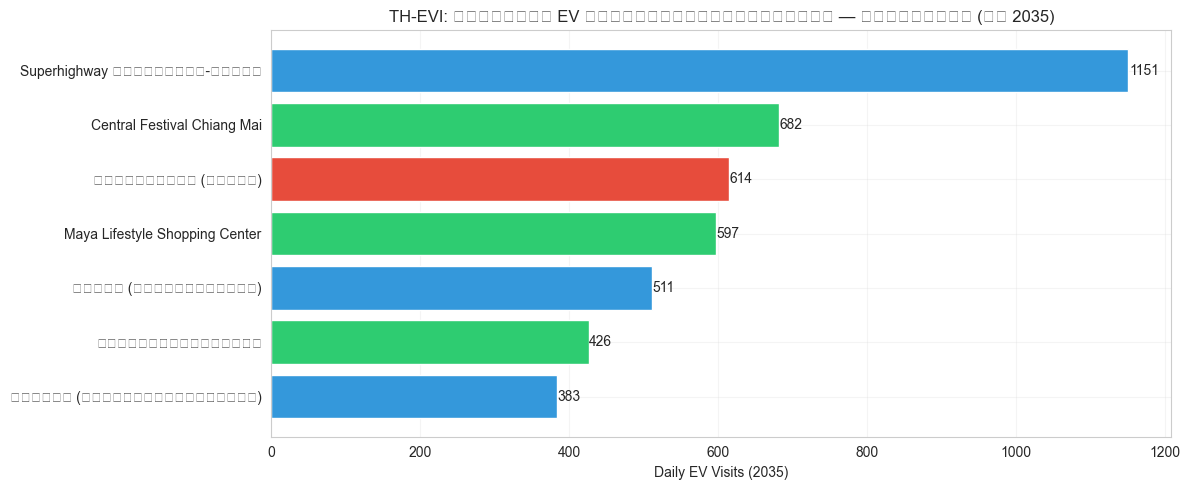

In [5]:
# Plot comparison across locations for target year 2035
df_2035 = df_demand[df_demand['year'] == 2035].sort_values('daily_ev_visits', ascending=True)

plt.figure(figsize=(12, 5))
bars = plt.barh(df_2035['location'], df_2035['daily_ev_visits'], 
        color=['#2ecc71' if t == 'destination' else '#3498db' if t == 'highway' else '#e74c3c' 
               for t in df_2035['type']])
plt.xlabel('Daily EV Visits (2035)')
plt.title('TH-EVI: คาดการณ์ EV ที่มาใช้บริการต่อวัน — เชียงใหม่ (ปี 2035)')
plt.grid(True, alpha=0.2)

# Add value labels
for bar, val in zip(bars, df_2035['daily_ev_visits']):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()

---
## 3. Time Series: Demand Growth (2025→2040)

C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pongw\AppData\Local\Temp\ipykernel_19940\1365964882.py:10: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) 

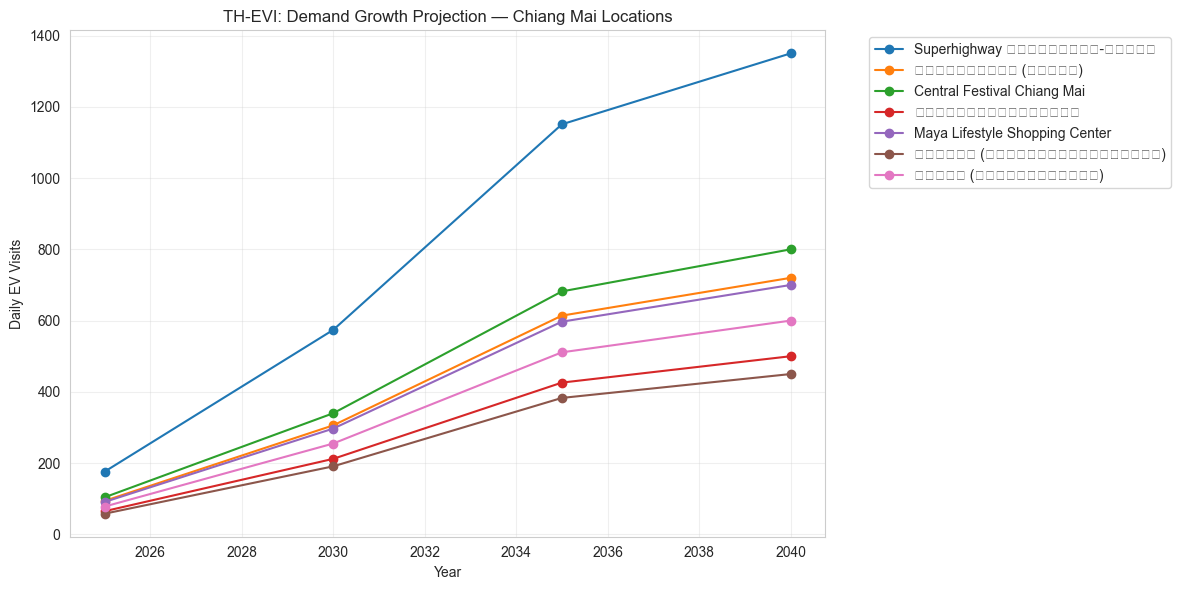

In [6]:
plt.figure(figsize=(12, 6))
for loc in df_demand['location'].unique():
    subset = df_demand[df_demand['location'] == loc]
    plt.plot(subset['year'], subset['daily_ev_visits'], 'o-', label=loc)

plt.xlabel('Year'); plt.ylabel('Daily EV Visits')
plt.title('TH-EVI: Demand Growth Projection — Chiang Mai Locations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Interactive Map

In [7]:
# Create map centered on Chiang Mai
m = folium.Map(location=[18.788, 98.985], zoom_start=12)

for loc_id, loc in LANDMARK_DB.items():
    r = demand.estimate_from_db(loc_id, 2035)
    
    # Color by type
    colors = {'highway': 'red', 'city_center': 'blue', 'destination': 'green'}
    color = colors.get(loc['type'], 'gray')
    
    popup_text = f"""
    <b>{loc['name']}</b><br>
    Type: {loc['type']}<br>
    <b>Daily EVs (2035): {r['daily_ev_visits']}</b><br>
    Daily kWh: {r['daily_kwh']} kWh
    """
    
    folium.CircleMarker(
        location=[loc['lat'], loc['lon']],
        radius=max(5, r['daily_ev_visits'] / 20),
        popup=folium.Popup(popup_text, max_width=300),
        color=color,
        fill=True,
        fill_opacity=0.6,
    ).add_to(m)

m

In [8]:
# Save map as HTML for sharing
m.save('chiang_mai_ev_demand_2035.html')
print('✅ Map saved to chiang_mai_ev_demand_2035.html')

✅ Map saved to chiang_mai_ev_demand_2035.html


---
## 5. Executive Summary

### Chiang Mai EV Demand (2035 Projection)

In [9]:
print('=' * 65)
print('  TH-EVI: Executive Summary — เชียงใหม่ Pilot ')
print('=' * 65)

summary = df_demand[df_demand['year'] == 2035].copy()
total_visits = summary['daily_ev_visits'].sum()
total_kwh = summary['daily_kwh'].sum()

print(f'\n📊 ปี 2035 (10 ปีข้างหน้า):')
print(f'   รวม daily EV visits (7 จุดสำรวจ): {total_visits} คัน/วัน')
print(f'   รวม daily energy demand: {total_kwh:,.0f} kWh/วัน')
print(f'   EV share ของ fleet เชียงใหม่: {model.get_ev_share(2035)*100:.1f}%')
print(f'   คาดการณ์ EV ในเชียงใหม่: {model.get_ev_population(2035):,} คัน')

print(f'\n📍 จุดที่มี demand สูงสุด (2035):')
top = summary.sort_values('daily_ev_visits', ascending=False).head(3)
for _, row in top.iterrows():
    print(f'   - {row["location"]}: {row["daily_ev_visits"]} คัน/วัน ({row["daily_kwh"]} kWh)')

print(f'\n📈 อัตราการเติบโต:')
g_2025 = df_demand[df_demand['year']==2025]['daily_ev_visits'].sum()
g_2040 = df_demand[df_demand['year']==2040]['daily_ev_visits'].sum()
cagr = ((g_2040/g_2025)**(1/15) - 1) * 100
print(f'   CAGR (2025→2040): {cagr:.1f}% ต่อปี')
print(f'   2025: {g_2025} คัน/วัน → 2040: {g_2040} คัน/วัน')
print()
print('=' * 65)

  TH-EVI: Executive Summary — เชียงใหม่ Pilot 

📊 ปี 2035 (10 ปีข้างหน้า):
   รวม daily EV visits (7 จุดสำรวจ): 4364 คัน/วัน
   รวม daily energy demand: 94,293 kWh/วัน
   EV share ของ fleet เชียงใหม่: 42.7%
   คาดการณ์ EV ในเชียงใหม่: 918,090 คัน

📍 จุดที่มี demand สูงสุด (2035):
   - Superhighway เชียงใหม่-ลำปาง: 1151 คัน/วัน (34530.0 kWh)
   - Central Festival Chiang Mai: 682 คัน/วัน (10230.0 kWh)
   - ประตูท่าแพ (เมือง): 614 คัน/วัน (7368.0 kWh)

📈 อัตราการเติบโต:
   CAGR (2025→2040): 14.6% ต่อปี
   2025: 666 คัน/วัน → 2040: 5120 คัน/วัน

